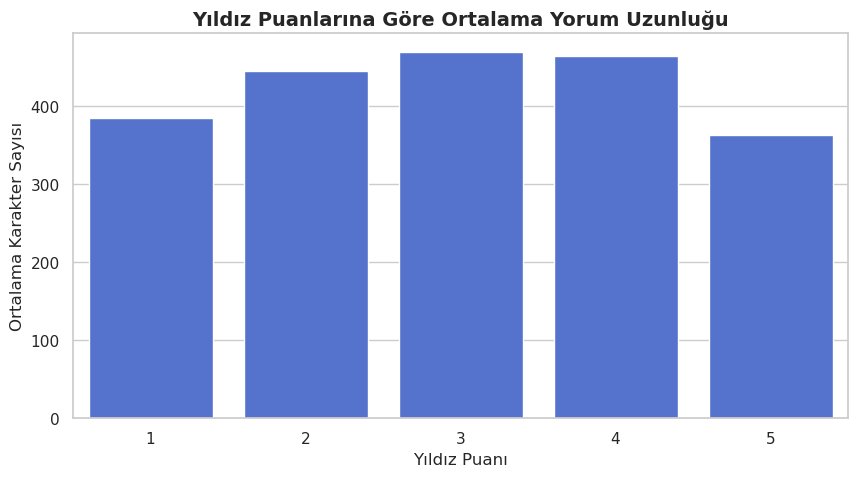

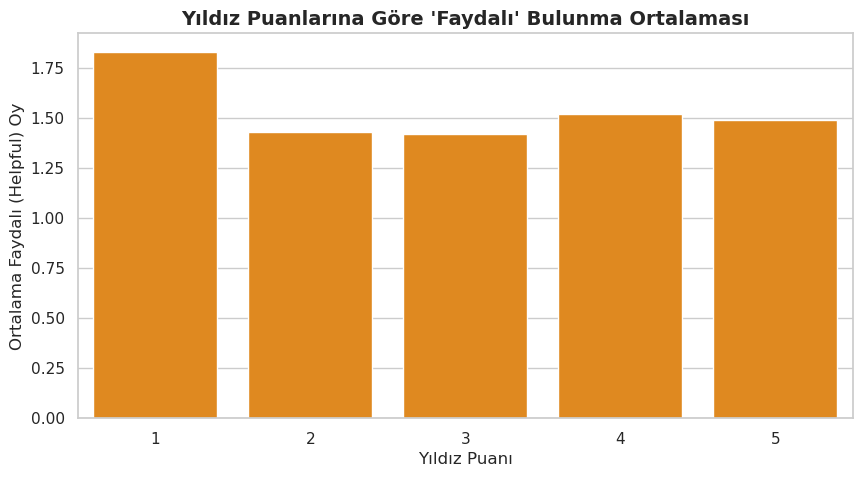

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Grafikleri daha şık ve okunaklı yapmak için Seaborn teması ayarlıyoruz
sns.set_theme(style="whitegrid", palette="muted")

# Spark'ın oluşturduğu parçalı CSV dosyalarını otomatik okuyup birleştiren fonksiyon
def read_spark_csv(folder_path):
    all_files = glob.glob(os.path.join(folder_path, "*.csv"))
    if not all_files:
        return None
    df_list = [pd.read_csv(f) for f in all_files]
    return pd.concat(df_list, ignore_index=True)

# 1. Veriyi Okuma
# Not: Jupyter Notebook 'work' (yani spark) klasörünün içinde olduğu için yollar output/ ile başlıyor
avg_votes_path = "output/eda_outputs/avg_votes_by_rating"
df_avg_votes = read_spark_csv(avg_votes_path)

if df_avg_votes is not None:
    # Veriyi yıldıza göre sıralayalım
    df_avg_votes = df_avg_votes.sort_values(by='star_rating')
    
    # --- GRAFİK 1: Yıldız Puanlarına Göre Ortalama İnceleme Uzunluğu ---
    plt.figure(figsize=(10, 5))
    ax1 = sns.barplot(data=df_avg_votes, x='star_rating', y='avg_review_length', color='royalblue')
    plt.title("Yıldız Puanlarına Göre Ortalama Yorum Uzunluğu", fontsize=14, fontweight='bold')
    plt.xlabel("Yıldız Puanı", fontsize=12)
    plt.ylabel("Ortalama Karakter Sayısı", fontsize=12)
    plt.show()

    # --- GRAFİK 2: Yıldız Puanlarına Göre Faydalı Bulunma Oranı ---
    plt.figure(figsize=(10, 5))
    ax2 = sns.barplot(data=df_avg_votes, x='star_rating', y='avg_helpful_votes', color='darkorange')
    plt.title("Yıldız Puanlarına Göre 'Faydalı' Bulunma Ortalaması", fontsize=14, fontweight='bold')
    plt.xlabel("Yıldız Puanı", fontsize=12)
    plt.ylabel("Ortalama Faydalı (Helpful) Oy", fontsize=12)
    plt.show()
else:
    print("Veri bulunamadı. Lütfen Spark EDA scriptinin çalıştığından emin olun.")

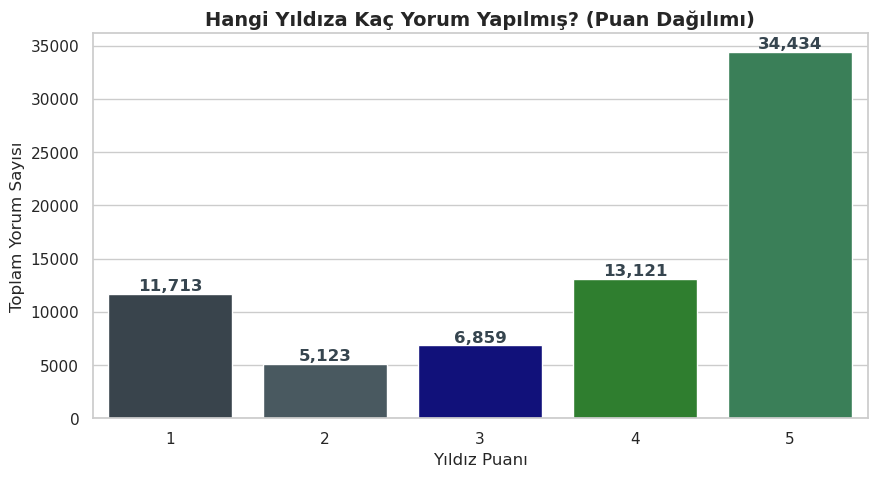

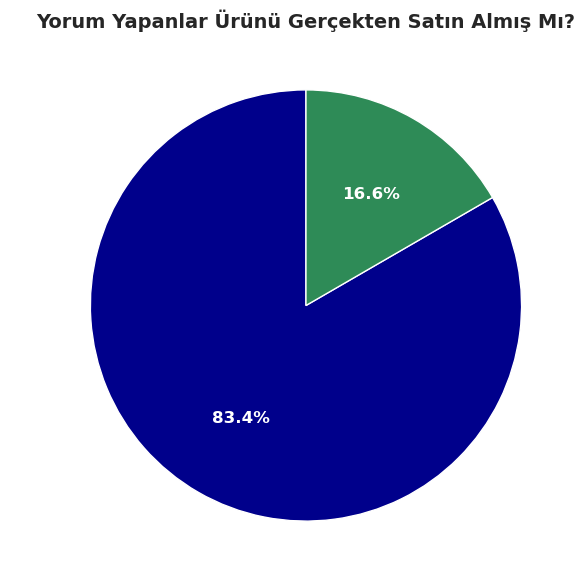

In [3]:
# --- ŞOVU BÜYÜTÜYORUZ: YENİ GRAFİKLER ---

# 1. Puan Dağılımı (Hangi yıldıza kaç kişi oy vermiş?)
rating_dist_path = "output/eda_outputs/rating_distribution"
df_rating = read_spark_csv(rating_dist_path)

if df_rating is not None:
    df_rating = df_rating.sort_values(by='star_rating')
    plt.figure(figsize=(10, 5))
    
    # Düz, minimalist ve yüksek kontrastlı renk paleti (Koyu Mavi, Antrasit, Yeşil tonları)
    custom_palette = ['#36454F', '#455a64', '#00008B', '#228B22', '#2E8B57']
    
    sns.barplot(data=df_rating, x='star_rating', y='count', hue='star_rating', palette=custom_palette, legend=False)
    plt.title("Hangi Yıldıza Kaç Yorum Yapılmış? (Puan Dağılımı)", fontsize=14, fontweight='bold')
    plt.xlabel("Yıldız Puanı", fontsize=12)
    plt.ylabel("Toplam Yorum Sayısı", fontsize=12)
    
    # Barların üzerine rakamları yazdırmak için minimalist bir dokunuş
    for index, value in enumerate(df_rating['count']):
        plt.text(index, value, f"{value:,}", ha='center', va='bottom', fontweight='bold', color='#36454F')
    plt.show()

# 2. Onaylı Satın Alma (Verified Purchase) Dağılımı (Pasta Grafiği)
verified_path = "output/eda_outputs/verified_distribution"
df_verified = read_spark_csv(verified_path)

if df_verified is not None:
    plt.figure(figsize=(7, 7))
    
    # Flat tasarım, dokusuz renkler
    colors = ['#00008B', '#2E8B57'] 
    
    # 'Y' (Yes) ve 'N' (No) durumlarına göre etiketler
    labels = df_verified['verified_purchase'].apply(lambda x: "Onaylı Alışveriş (Y)" if x == "Y" else "Onaysız (N)")
    
    # Pasta grafiği (düz tasarım, gölgesiz)
    plt.pie(df_verified['count'], labels=labels, colors=colors, autopct='%1.1f%%', 
            startangle=90, textprops={'fontsize': 12, 'weight': 'bold', 'color': 'white'})
    plt.title("Yorum Yapanlar Ürünü Gerçekten Satın Almış Mı?", fontsize=14, fontweight='bold')
    plt.show()